<a href="https://colab.research.google.com/github/astro-prog/SMS_Spam_detection_mini_project/blob/main/SMS_Spam_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installation and Import of Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Downloading the Dataset

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
# The file has no header, so we define column names
df = pd.read_table(url, header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Exploring Data

In [3]:
print(df.info())
print(df.describe())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30
label
ham     4825
spam     747
Name: count, dtype: int64


Data Preprocessing

In [4]:
# Convert labels to numbers: ham = 0, spam = 1
df['label_num'] = df.label.map({'ham':0, 'spam':1})

# Define features (X) and target (y)
X = df.message
y = df.label_num

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Exploratory Data Analysis (EDA)

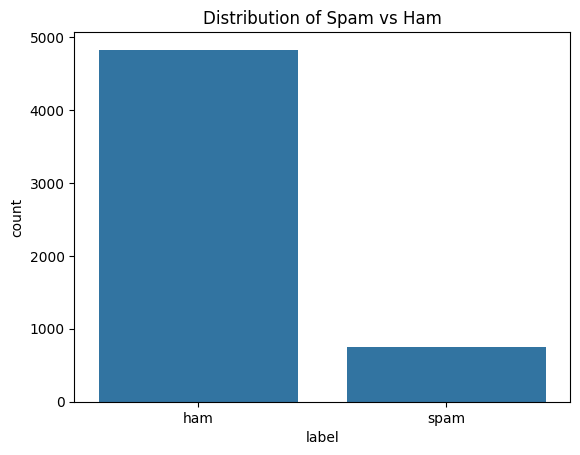

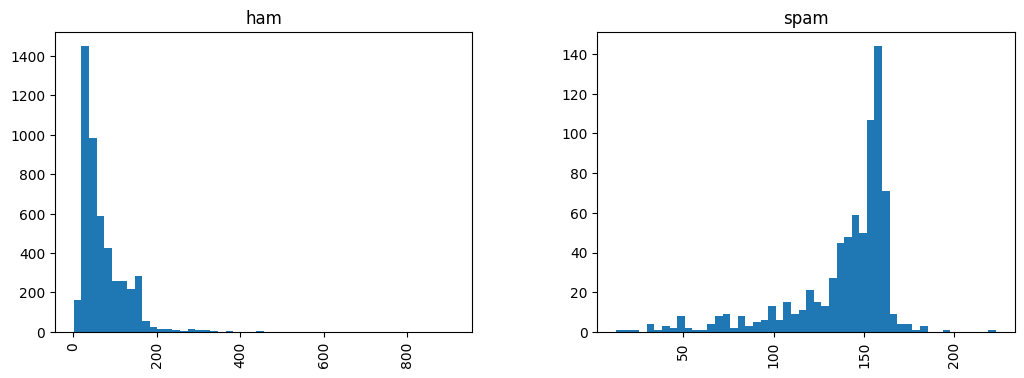

In [5]:
sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham')
plt.show()

# Optional: Visualize message lengths
df['length'] = df['message'].apply(len)
df.hist(column='length', by='label', bins=50, figsize=(12,4))
plt.show()

Vectorization & Training the Model

In [6]:
# Initialize Vectorizer
vect = CountVectorizer()

# Convert text into a document-term matrix
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# Initialize and Train Naive Bayes Model
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)

MultinomialNB()

Evaluating the Model

In [7]:
# Make predictions
y_pred = nb.predict(X_test_dtm)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 99.19%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



Visualizing Results

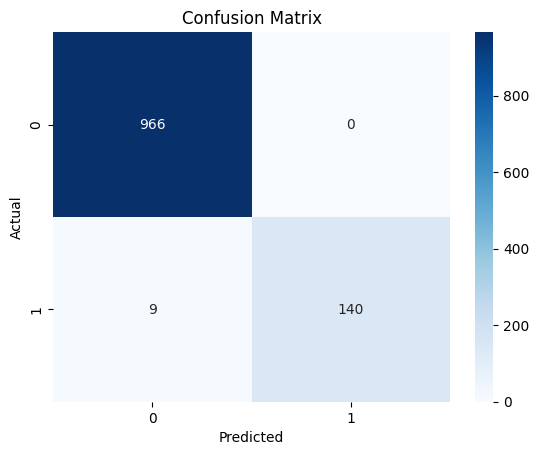

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Testing the Model (Manual Test)

In [9]:
def predict_spam(new_message):
    new_message_dtm = vect.transform([new_message])
    prediction = nb.predict(new_message_dtm)
    return "SPAM" if prediction[0] == 1 else "HAM"

# Test cases
print(predict_spam("Congratulations! You've won a $1,000 Walmart gift card. Click here to claim."))
print(predict_spam("Hey, are we still meeting for lunch at 12?"))

SPAM
HAM
